# Import Dataset

In [31]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import sys
!"{sys.executable}" -m pip install kagglehub
import kagglehub
puneet6060_intel_image_classification_path = kagglehub.dataset_download('puneet6060/intel-image-classification')
adityajn105_flickr8k_path = kagglehub.dataset_download('adityajn105/flickr8k')

print('Data source import complete.')

# Buka kaggle.com/settings/api buat dapet token API nya


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Data source import complete.


In [32]:
import sys
import os
import json
import time

sys.path.append(os.path.abspath(".."))

import matplotlib.pyplot as plt
import cv2
import pandas as pd
from PIL import Image, ImageOps, ImageEnhance
import seaborn as sns
import random
import numpy as np
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
from cnn.utils import load_image, load_batch, build_dataset_from_directory
import tensorflow as tf
from tensorflow import keras
print(tf.config.list_physical_devices('GPU'))


from cnn.train_keras import build_cnn_model
from cnn.evaluate import evaluate_keras
from tensorflow.keras import layers as KL

from sklearn.metrics import confusion_matrix, classification_report, f1_score

# Define a random seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

[]


In [33]:
for dirname, _, filenames in os.walk(puneet6060_intel_image_classification_path):
    print(dirname)

    for filename in filenames[:5]:
        print("  ", filename)

    print()

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_pred

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_pred\seg_pred
   10004.jpg
   10005.jpg
   10012.jpg
   10013.jpg
   10017.jpg

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test\buildings
   20057.jpg
   20060.jpg
   20061.jpg
   20064.jpg
   20073.jpg

C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test\forest
   20056.jpg
   20062.jpg
   20082.jpg
   20089.jpg
   20091.jpg

C:\Users\VICTUS 16\.cache\kaggleh

In [34]:
for dirname, _, filenames in os.walk(adityajn105_flickr8k_path):
    print(dirname)

    for filename in filenames[:5]:
        print("  ", filename)

    print()

C:\Users\VICTUS 16\.cache\kagglehub\datasets\adityajn105\flickr8k\versions\1
   captions.txt

C:\Users\VICTUS 16\.cache\kagglehub\datasets\adityajn105\flickr8k\versions\1\Images
   1000268201_693b08cb0e.jpg
   1001773457_577c3a7d70.jpg
   1002674143_1b742ab4b8.jpg
   1003163366_44323f5815.jpg
   1007129816_e794419615.jpg



# 1. Exploratory Data Analysis (EDA)

## 1.1 Melihat Isi Dataset

Displaying sample images from different categories:

Showing examples for category: 'forest'


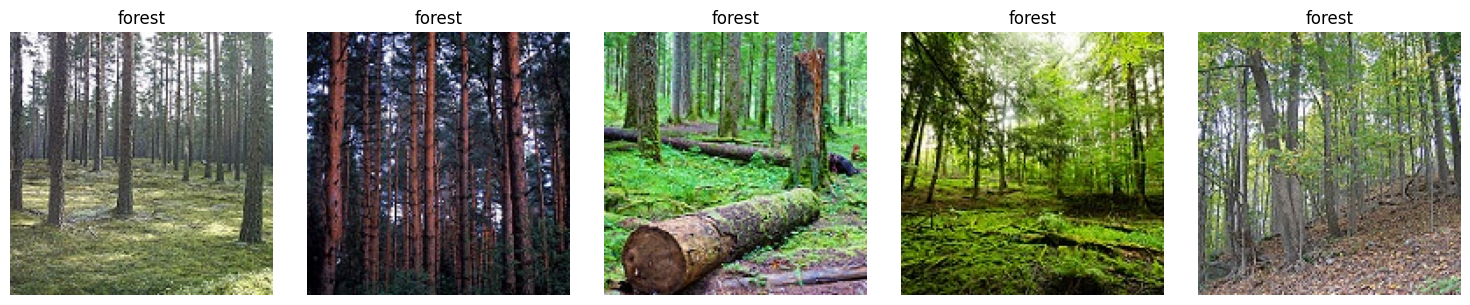

Showing examples for category: 'glacier'


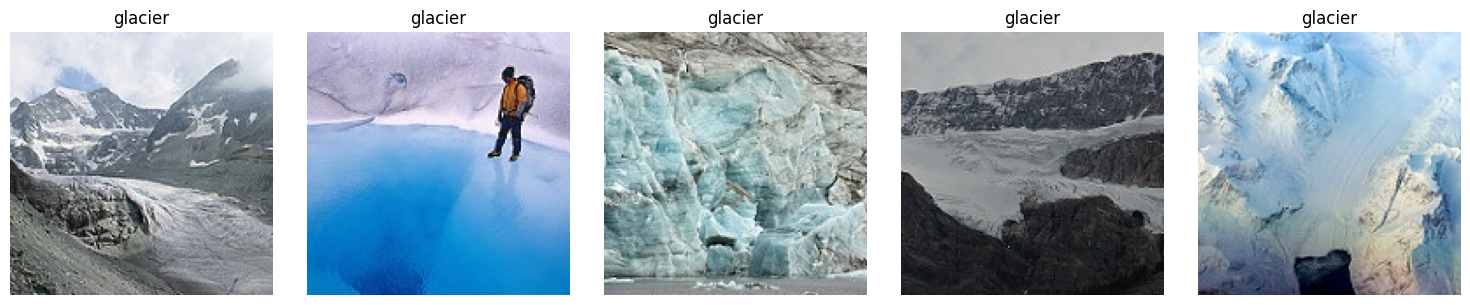

Showing examples for category: 'mountain'


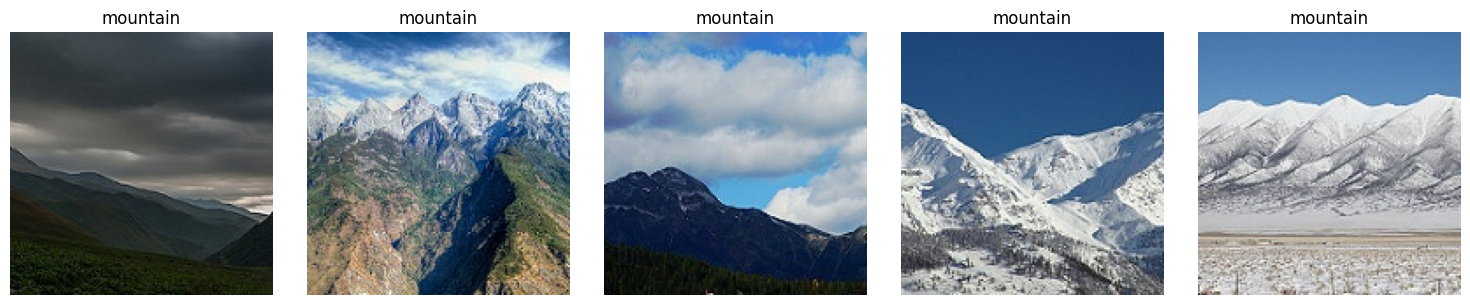

Showing examples for category: 'buildings'


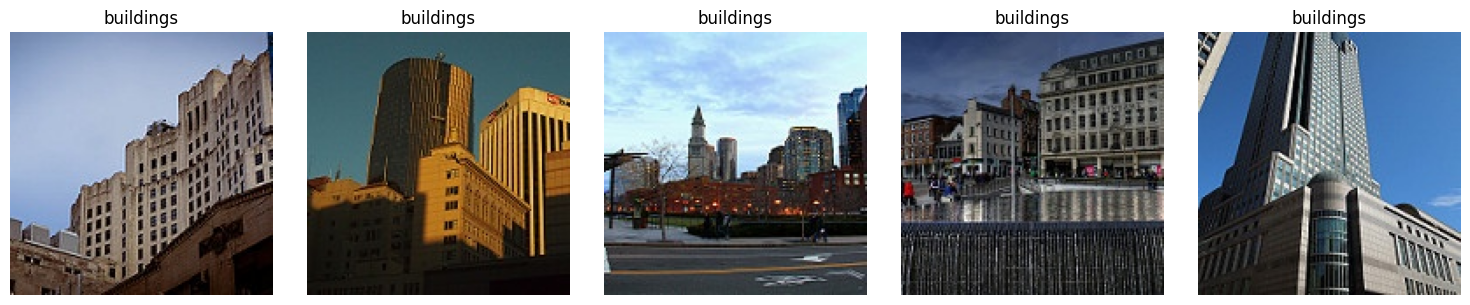

In [35]:
# Define the base path to the dataset (already defined from cell TN1THskPAqn8)
dataset_path = puneet6060_intel_image_classification_path

# Define the base path for the training images
train_base_path = os.path.join(dataset_path, 'seg_train', 'seg_train')

# Function to display examples from a specific category
def show_category_examples(base_path, category_name, n=5):
    category_dir = os.path.join(base_path, category_name)
    if not os.path.exists(category_dir):
        print(f"Directory for category '{category_name}' not found: {category_dir}")
        return

    # Get a list of image files in the category directory
    image_files = [f for f in os.listdir(category_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if not image_files:
        print(f"No image files found in category '{category_name}': {category_dir}")
        return

    # Select 'n' random images if there are more than 'n' available, otherwise take all
    selected_files = random.sample(image_files, min(n, len(image_files)))

    plt.figure(figsize=(15, 3))
    for i, filename in enumerate(selected_files):
        img_path = os.path.join(category_dir, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib

            plt.subplot(1, len(selected_files), i + 1)
            plt.imshow(img)
            plt.axis('off')
            plt.title(f'{category_name}')
        else:
            print(f"Could not load image: {img_path}")
    plt.tight_layout()
    plt.show()

# Get a list of all categories (subdirectories) in the training set
categories = [d for d in os.listdir(train_base_path) if os.path.isdir(os.path.join(train_base_path, d))]

print("Displaying sample images from different categories:\n")

# Display examples from a few selected categories
# You can change these categories or add more if desired
sample_categories = ['forest', 'glacier', 'mountain', 'buildings'] 

for category in sample_categories:
    if category in categories:
        print(f"Showing examples for category: '{category}'")
        show_category_examples(train_base_path, category, n=5)
    else:
        print(f"Category '{category}' not found in training set.")


## 1.2 Distribusi Sample per Kelas

Plotting sample distribution per class...


C:\Users\VICTUS 16\AppData\Local\Temp\ipykernel_39492\4133584701.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=category_df, x='Category', palette='viridis')


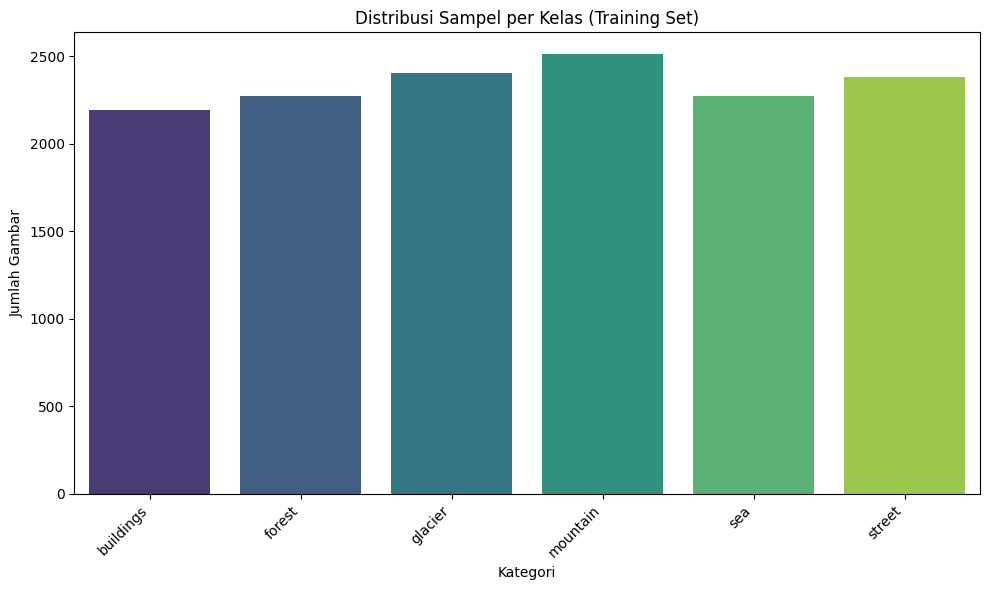


Summary of image counts per category:
- buildings: 2191 images
- forest: 2271 images
- glacier: 2404 images
- mountain: 2512 images
- sea: 2274 images
- street: 2382 images


In [36]:
train_base_path = os.path.join(dataset_path, 'seg_train', 'seg_train')

# Get a list of all categories (subdirectories) in the training set
categories = [d for d in os.listdir(train_base_path) if os.path.isdir(os.path.join(train_base_path, d))]

# Collect category labels for all images to create a distribution plot
all_image_categories = []
category_counts = {}

print("Collecting image counts per category...")
for category_name in categories:
    category_dir = os.path.join(train_base_path, category_name)
    image_files = [f for f in os.listdir(category_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    count = len(image_files)
    category_counts[category_name] = count
    all_image_categories.extend([category_name] * count)

# Create a DataFrame for the countplot
category_df = pd.DataFrame({
    'Category': all_image_categories
})

print("Plotting sample distribution per class...")
plt.figure(figsize=(10, 6))
sns.countplot(data=category_df, x='Category', palette='viridis')
plt.title('Distribusi Sampel per Kelas (Training Set)')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Gambar')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

print("\nSummary of image counts per category:")
for category, count in category_counts.items():
    print(f"- {category}: {count} images")

## 1.3 Variasi Dimensi Gambar dan Aspect Ratio

Processing training images:   0%|          | 0/14034 [00:00<?, ?it/s]


Plotting distributions...


<Figure size 800x700 with 0 Axes>

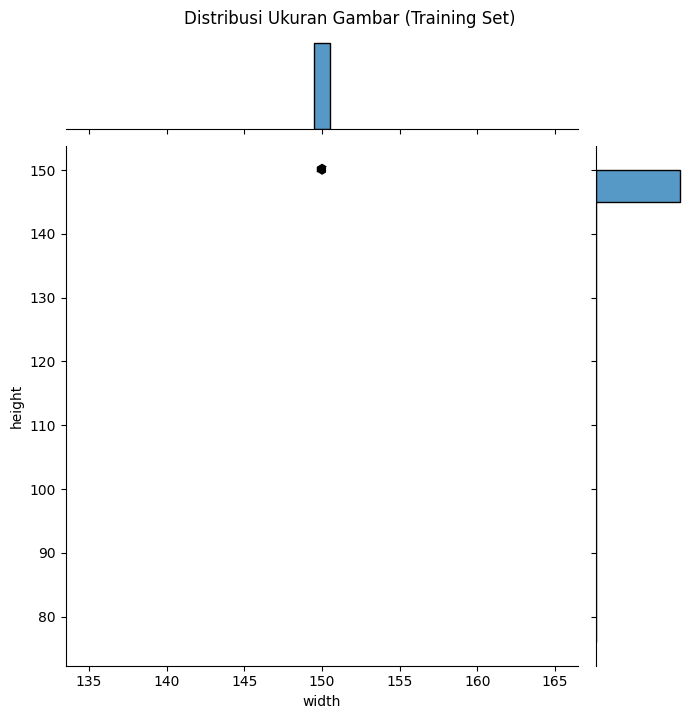

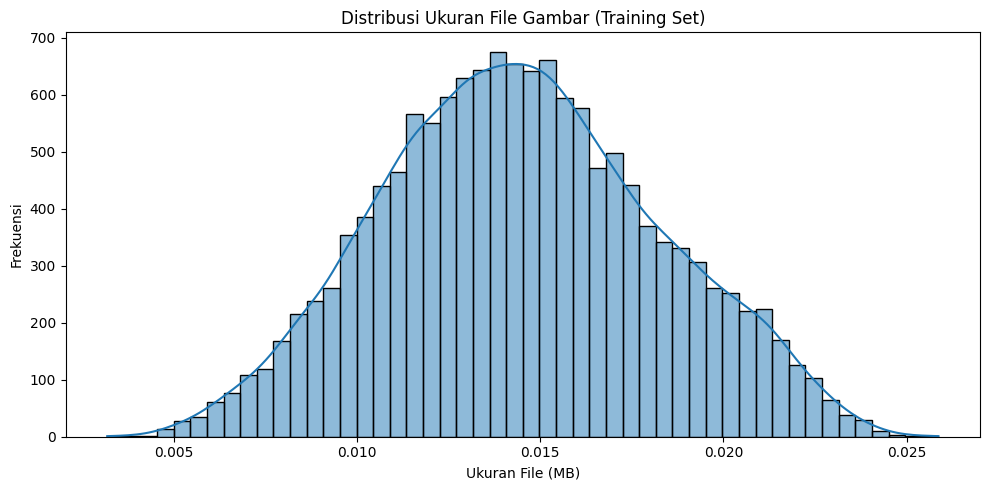

DPI values are largely uniform or not present in image metadata. Unique DPIs: [72.]

--- Summary Statistics (Training Set) ---
Total images processed: 14034
Min Width: 150
Max Width: 150
Average Width: 150.00
Min Height: 76
Max Height: 150
Average Height: 149.91
Min File Size (MB): 0.00
Max File Size (MB): 0.03
Average File Size (MB): 0.01
Min DPI: 72.00
Max DPI: 72.00
Average DPI: 72.00


In [37]:
dataset_path = puneet6060_intel_image_classification_path
seg_train_path = os.path.join(dataset_path, 'seg_train', 'seg_train')

def get_image_paths(base_dir):
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                yield os.path.join(root, file)

print("Collecting image metadata from the training set...")
dims = []
file_sizes = []
dpi_values = []

# Get all image paths from the training directory
image_paths = list(get_image_paths(seg_train_path))

for img_path in tqdm(image_paths, desc="Processing training images"):
    try:
        with Image.open(img_path) as img:
            dims.append(img.size)
            file_sizes.append(os.path.getsize(img_path))
            # Get DPI, default to (72, 72) if not found
            dpi_values.append(img.info.get('dpi', (72, 72)))
    except Exception as e:
        print(f"Could not process image {img_path}: {e}")

dims_df = pd.DataFrame(dims, columns=['width', 'height'])
dims_df['file_size'] = file_sizes

processed_dpi_list = []
for dpi_entry in dpi_values:
    try:
        # DPI can be a tuple (x, y) or a single value. Take the first element if it's a tuple.
        if isinstance(dpi_entry, tuple):
            processed_dpi_list.append(float(dpi_entry[0]))
        else:
            processed_dpi_list.append(float(dpi_entry))
    except (ValueError, TypeError):
        processed_dpi_list.append(72.0) # Default DPI if extraction fails

dims_df['dpi'] = processed_dpi_list

# Plotting distributions
print("\nPlotting distributions...")

# Distribution of Image Dimensions (Width vs Height)
plt.figure(figsize=(8, 7))
sns.jointplot(data=dims_df, x='width', y='height', kind='hex', height=7)
plt.suptitle("Distribusi Ukuran Gambar (Training Set)", y=1.02)
plt.show()

# Distribution of File Sizes
plt.figure(figsize=(10, 5))
# Convert bytes to MB for better readability
sns.histplot(dims_df['file_size'] / (1024 * 1024), kde=True, bins=50)
plt.title("Distribusi Ukuran File Gambar (Training Set)")
plt.xlabel("Ukuran File (MB)")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# Distribution of Image Resolution (DPI)
# Only plot if there's meaningful variation in DPI values
if dims_df['dpi'].nunique() > 1:
    plt.figure(figsize=(10, 5))
    sns.histplot(dims_df['dpi'], kde=True, bins=50)
    plt.title("Distribusi Resolusi Gambar (DPI) (Training Set)")
    plt.xlabel("DPI")
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()
else:
    print(f"DPI values are largely uniform or not present in image metadata. Unique DPIs: {dims_df['dpi'].unique()}")

print("\n--- Summary Statistics (Training Set) ---")
print(f"Total images processed: {len(dims_df)}")
print(f"Min Width: {dims_df['width'].min()}")
print(f"Max Width: {dims_df['width'].max()}")
print(f"Average Width: {dims_df['width'].mean():.2f}")
print(f"Min Height: {dims_df['height'].min()}")
print(f"Max Height: {dims_df['height'].max()}")
print(f"Average Height: {dims_df['height'].mean():.2f}")
print(f"Min File Size (MB): {(dims_df['file_size'].min() / (1024 * 1024)):.2f}")
print(f"Max File Size (MB): {(dims_df['file_size'].max() / (1024 * 1024)):.2f}")
print(f"Average File Size (MB): {(dims_df['file_size'].mean() / (1024 * 1024)):.2f}")
print(f"Min DPI: {dims_df['dpi'].min():.2f}")
print(f"Max DPI: {dims_df['dpi'].max():.2f}")
print(f"Average DPI: {dims_df['dpi'].mean():.2f}")

## 1.4 Distribusi Intensitas Nilai Piksel per Kelas

Processing images in buildings:   0%|          | 0/30 [00:00<?, ?it/s]

Processing images in forest:   0%|          | 0/30 [00:00<?, ?it/s]

Processing images in glacier:   0%|          | 0/30 [00:00<?, ?it/s]

Processing images in mountain:   0%|          | 0/30 [00:00<?, ?it/s]

Processing images in sea:   0%|          | 0/30 [00:00<?, ?it/s]

Processing images in street:   0%|          | 0/30 [00:00<?, ?it/s]


Plotting average pixel intensity distributions...


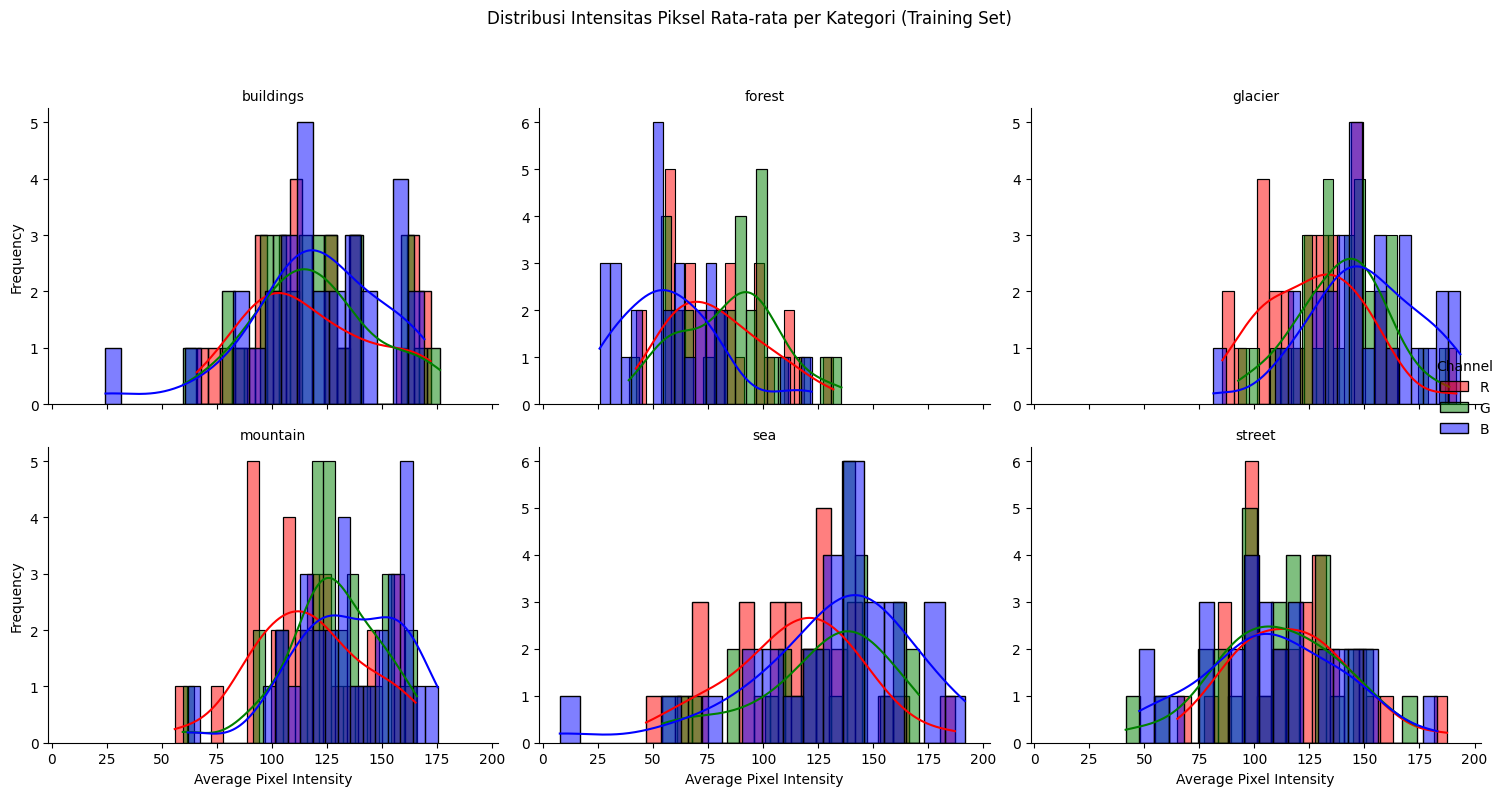

In [38]:
train_base_path = os.path.join(dataset_path, 'seg_train', 'seg_train')
categories = [d for d in os.listdir(train_base_path) if os.path.isdir(os.path.join(train_base_path, d))]
sample_size = 30

def get_average_pixel_intensities(image_filenames, image_dir):
    avg_r, avg_g, avg_b = [], [], []
    for img_name in tqdm(image_filenames, desc=f"Processing images in {os.path.basename(image_dir)}", leave=False):
        try:
            img_path = os.path.join(image_dir, img_name)
            with Image.open(img_path).convert('RGB') as img:
                img_array = np.array(img)
                avg_r.append(np.mean(img_array[:,:,0]))
                avg_g.append(np.mean(img_array[:,:,1]))
                avg_b.append(np.mean(img_array[:,:,2]))
        except Exception as e:
            print(f"Error processing image {img_name} in {image_dir}: {e}")
    return avg_r, avg_g, avg_b

print("Collecting average pixel intensities for each category...")

all_avg_intensities = []
all_channels = []
all_categories = []

for category_name in categories:
    category_dir = os.path.join(train_base_path, category_name)
    
    # Get a list of image files in the category directory
    image_files = [f for f in os.listdir(category_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if not image_files:
        print(f"No image files found in category '{category_name}': {category_dir}")
        continue

    sampled_category_files = random.sample(image_files, min(len(image_files), sample_size))
    avg_r, avg_g, avg_b = get_average_pixel_intensities(sampled_category_files, category_dir)

    # Extend the master lists
    all_avg_intensities.extend(avg_r + avg_g + avg_b)
    all_channels.extend(['R']*len(avg_r) + ['G']*len(avg_g) + ['B']*len(avg_b))
    all_categories.extend([category_name]*(len(avg_r) + len(avg_g) + len(avg_b)))


pixel_data_avg_df = pd.DataFrame({
    'Average Intensity': all_avg_intensities,
    'Channel': all_channels,
    'Category': all_categories
})
print("\nPlotting average pixel intensity distributions...")

num_categories = len(categories)
col_wrap_val = min(num_categories, 3)

g = sns.FacetGrid(pixel_data_avg_df, col='Category', col_wrap=col_wrap_val, height=4, aspect=1.2,
                  hue='Channel', palette={'R':'red', 'G':'green', 'B':'blue'}, sharex=True, sharey=False)

g.map(sns.histplot, 'Average Intensity', kde=True, bins=20)

g.set_titles("{col_name}")
g.set_axis_labels("Average Pixel Intensity", "Frequency")
g.add_legend(title="Channel")
plt.suptitle("Distribusi Intensitas Piksel Rata-rata per Kategori (Training Set)", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

## 1.5 Deteksi Outlier (Brightness dan Dimensi)

[EDA Outlier] Mengumpulkan statistik gambar (brightness & dimensi)...
Ditemukan 117 outlier dari 14034 gambar (threshold: [32.4, 196.8])


C:\Users\VICTUS 16\AppData\Local\Temp\ipykernel_39492\1027341727.py:83: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_per_class, labels=classes_order, patch_artist=True)


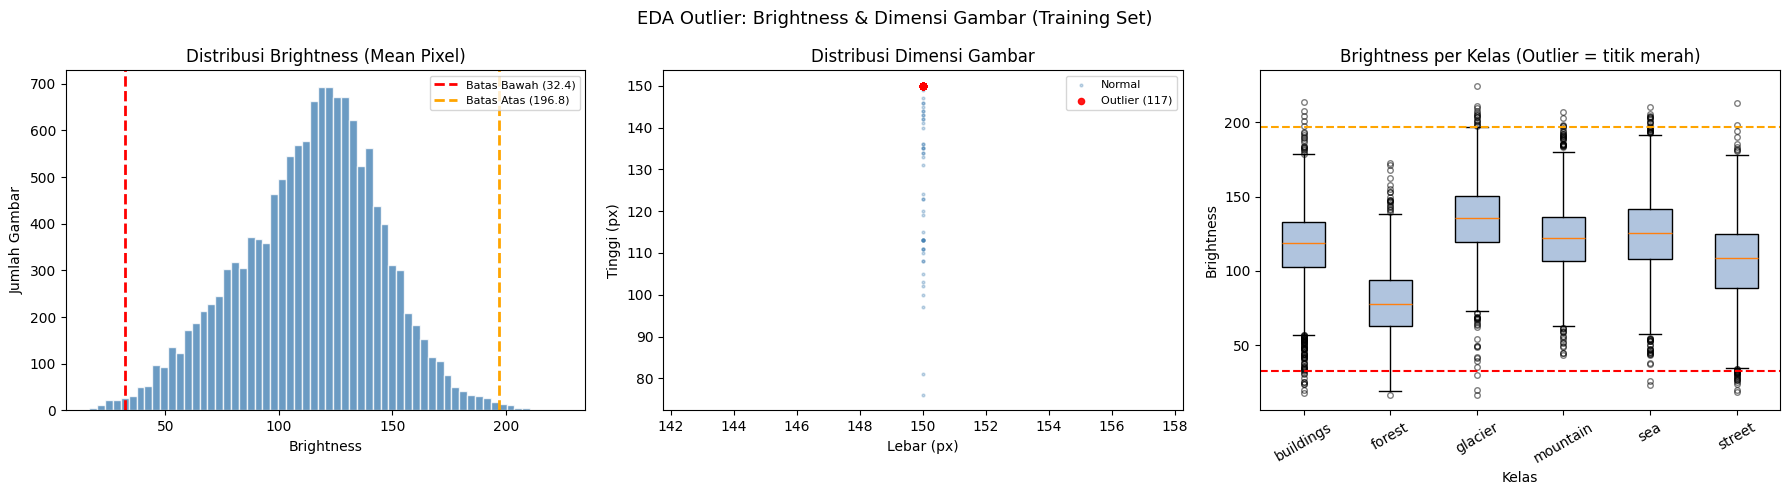

Selesai. 117 path outlier disimpan ke OUTLIER_PATHS_SET.


In [39]:
print("[EDA Outlier] Mengumpulkan statistik gambar (brightness & dimensi)...")

train_base_path = os.path.join(puneet6060_intel_image_classification_path,
                               'seg_train', 'seg_train')

eda_paths, eda_labels_str, eda_brightness, eda_widths, eda_heights = [], [], [], [], []

for cls in sorted(os.listdir(train_base_path)):
    cls_dir = os.path.join(train_base_path, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        fp = os.path.join(cls_dir, fname)
        try:
            with Image.open(fp) as img:
                arr = np.array(img.convert('RGB'), dtype=np.float32)
                eda_brightness.append(float(arr.mean()))
                eda_widths.append(img.width)
                eda_heights.append(img.height)
                eda_paths.append(fp)
                eda_labels_str.append(cls)
        except Exception:
            pass

eda_df = pd.DataFrame({
    'path': eda_paths,
    'class': eda_labels_str,
    'brightness': eda_brightness,
    'width': eda_widths,
    'height': eda_heights,
})

# Hitung batas outlier brightness dengan IQR
Q1_b  = eda_df['brightness'].quantile(0.25)
Q3_b  = eda_df['brightness'].quantile(0.75)
IQR_b = Q3_b - Q1_b
LOW_BRIGHT  = Q1_b - 1.5 * IQR_b
HIGH_BRIGHT = Q3_b + 1.5 * IQR_b

# Simpan threshold ke variabel global agar dipakai di sel 2.3
OUTLIER_BRIGHTNESS_LOW  = max(LOW_BRIGHT,  20.0)   # hard-floor 20
OUTLIER_BRIGHTNESS_HIGH = min(HIGH_BRIGHT, 240.0)  # hard-ceil 240

outlier_mask = (
    (eda_df['brightness'] < OUTLIER_BRIGHTNESS_LOW) |
    (eda_df['brightness'] > OUTLIER_BRIGHTNESS_HIGH)
)
n_outliers = outlier_mask.sum()
print(f"Ditemukan {n_outliers} outlier dari {len(eda_df)} gambar "
      f"(threshold: [{OUTLIER_BRIGHTNESS_LOW:.1f}, {OUTLIER_BRIGHTNESS_HIGH:.1f}])")

# Plot 1: Distribusi Brightness + IQR fence
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(eda_df['brightness'], bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(OUTLIER_BRIGHTNESS_LOW,  color='red',    linestyle='--', lw=2,
           label=f'Batas Bawah ({OUTLIER_BRIGHTNESS_LOW:.1f})')
ax.axvline(OUTLIER_BRIGHTNESS_HIGH, color='orange', linestyle='--', lw=2,
           label=f'Batas Atas ({OUTLIER_BRIGHTNESS_HIGH:.1f})')
ax.set_title('Distribusi Brightness (Mean Pixel)')
ax.set_xlabel('Brightness'); ax.set_ylabel('Jumlah Gambar')
ax.legend(fontsize=8)

# Plot 2: Scatter Width vs Height, warna = outlier
ax2 = axes[1]
normal_df  = eda_df[~outlier_mask]
outlier_df = eda_df[outlier_mask]
ax2.scatter(normal_df['width'],  normal_df['height'],
            s=4, alpha=0.3, color='steelblue', label='Normal')
ax2.scatter(outlier_df['width'], outlier_df['height'],
            s=20, alpha=0.9, color='red', label=f'Outlier ({n_outliers})')
ax2.set_title('Distribusi Dimensi Gambar')
ax2.set_xlabel('Lebar (px)'); ax2.set_ylabel('Tinggi (px)')
ax2.legend(fontsize=8)

# Plot 3: Boxplot brightness per kelas
ax3 = axes[2]
classes_order = sorted(eda_df['class'].unique())
data_per_class = [eda_df[eda_df['class'] == c]['brightness'].values for c in classes_order]
bp = ax3.boxplot(data_per_class, labels=classes_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
for flier in bp['fliers']:
    flier.set(marker='o', color='red', markersize=4, alpha=0.5)
ax3.axhline(OUTLIER_BRIGHTNESS_LOW,  color='red',    linestyle='--', lw=1.5)
ax3.axhline(OUTLIER_BRIGHTNESS_HIGH, color='orange', linestyle='--', lw=1.5)
ax3.set_title('Brightness per Kelas (Outlier = titik merah)')
ax3.set_xlabel('Kelas'); ax3.set_ylabel('Brightness')
ax3.tick_params(axis='x', rotation=30)

plt.suptitle('EDA Outlier: Brightness & Dimensi Gambar (Training Set)', fontsize=13)
plt.tight_layout()
plt.show()

OUTLIER_PATHS_SET = set(eda_df[outlier_mask]['path'].tolist())
print(f"Selesai. {len(OUTLIER_PATHS_SET)} path outlier disimpan ke OUTLIER_PATHS_SET.")


# 2. Data Cleaning and Preprocessing

## 2.1 Resizing dan Normalisasi Gambar


--- Preprocessing Gambar ---


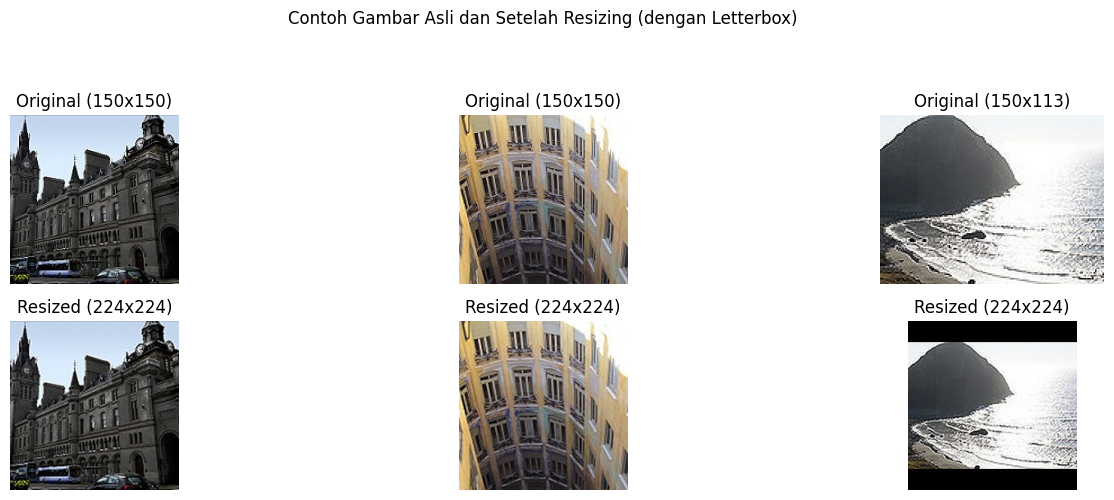


Shape dari gambar yang dinormalisasi: (224, 224, 3)
Min value dari gambar yang dinormalisasi: -2.1179
Max value dari gambar yang dinormalisasi: 2.6400
Mean value dari gambar yang dinormalisasi: 0.2520


In [40]:
def letterbox_resize(img, target_size=224):
    # Resize gambar dengan padding agar rasio aspek terjaga
    original_width, original_height = img.size
    ratio = min(target_size / original_width, target_size / original_height)
    new_width = int(original_width * ratio)
    new_height = int(original_height * ratio)
    
    img = img.resize((new_width, new_height), Image.LANCZOS)
    
    new_img = Image.new("RGB", (target_size, target_size), (0, 0, 0)) # Hitam sebagai padding
    offset = ((target_size - new_width) // 2, (target_size - new_height) // 2)
    new_img.paste(img, offset)
    return new_img

def augment_image(img):
    # Melakukan augmentasi gambar secara acak (flip horizontal, penyesuaian kecerahan)
    if random.random() < 0.5:
        img = ImageOps.mirror(img)  # flip horizontal
    if random.random() < 0.5:
        enhancer = ImageEnhance.Brightness(img)
        img = enhancer.enhance(random.uniform(0.8, 1.2))  # adjust brightness
    return img

def crop_partial(img, portion=0.2):
    # Melakukan crop sebagian gambar secara acak dan mengubah ukurannya kembali
    width, height = img.size
    crop_width = int(width * portion)
    crop_height = int(height * portion)

    left = random.randint(0, width - crop_width)
    top = random.randint(0, height - crop_height)
    right = left + crop_width
    bottom = top + crop_height

    img = img.crop((left, top, right, bottom))
    img = img.resize((224, 224), Image.LANCZOS)
    return img

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def load_and_preprocess_image(img_path, target_size=224, augment=False, use_partial_crop=False):
    # Memuat, mengubah ukuran, melakukan augmentasi, dan menormalisasi gambar
    try:
        with Image.open(img_path).convert("RGB") as img:
            if augment and use_partial_crop:
                img_processed = crop_partial(img, portion=0.2)
            else:
                img_processed = letterbox_resize(img, target_size=target_size)

            if augment:
                img_processed = augment_image(img_processed)
            
            img_arr = np.array(img_processed) / 255.0
            img_arr = (img_arr - IMAGENET_MEAN) / IMAGENET_STD
            
            return img_processed, img_arr
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None, None

def get_random_image_paths(base_dir, num_samples=3):
    # Mendapatkan jalur ke beberapa gambar acak dari seluruh kategori
    all_image_paths = []
    for root, _, files in os.walk(base_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_image_paths.append(os.path.join(root, file))
    
    if len(all_image_paths) < num_samples:
        print(f"Warning: Not enough images ({len(all_image_paths)}) to sample {num_samples} from {base_dir}. Sampling all available.")
        return all_image_paths
    return random.sample(all_image_paths, num_samples)


print("\n--- Preprocessing Gambar ---")

train_base_path = os.path.join(dataset_path, 'seg_train', 'seg_train')
sample_image_paths = get_random_image_paths(train_base_path, num_samples=3)

if not sample_image_paths:
    print("Tidak ada gambar sampel yang ditemukan untuk demonstrasi.")
else:
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_image_paths):
        original_img = Image.open(img_path).convert("RGB")
        resized_img_pil, normalized_img_arr = load_and_preprocess_image(img_path, target_size=224, augment=False, use_partial_crop=False)
        
        if original_img and resized_img_pil is not None:
            # Display original image
            plt.subplot(2, len(sample_image_paths), i + 1)
            plt.imshow(original_img)
            plt.title(f"Original ({original_img.size[0]}x{original_img.size[1]})")
            plt.axis('off')

            # Display resized (letterboxed) image
            plt.subplot(2, len(sample_image_paths), i + 1 + len(sample_image_paths))
            plt.imshow(resized_img_pil)
            plt.title(f"Resized (224x224)")
            plt.axis('off')

    plt.suptitle("Contoh Gambar Asli dan Setelah Resizing (dengan Letterbox)", y=1.02)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    if normalized_img_arr is not None:
        print(f"\nShape dari gambar yang dinormalisasi: {normalized_img_arr.shape}")
        print(f"Min value dari gambar yang dinormalisasi: {normalized_img_arr.min():.4f}")
        print(f"Max value dari gambar yang dinormalisasi: {normalized_img_arr.max():.4f}")
        print(f"Mean value dari gambar yang dinormalisasi: {normalized_img_arr.mean():.4f}")

## 2.2 Pembagian Dataset

In [41]:
dataset_path    = puneet6060_intel_image_classification_path
train_base_path = os.path.join(dataset_path, 'seg_train', 'seg_train')
test_base_path  = os.path.join(dataset_path, 'seg_test',  'seg_test')

IMG_SIZE   = 150
BATCH_SIZE = 32
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# 1. Kumpulkan paths & labels 
print("--- Membangun dataset dari direktori ---")

train_meta = build_dataset_from_directory(
    root_dir   = dataset_path,
    target_size = (IMG_SIZE, IMG_SIZE),
    splits      = ('seg_train/seg_train',)
)
test_meta = build_dataset_from_directory(
    root_dir   = dataset_path,
    target_size = (IMG_SIZE, IMG_SIZE),
    splits      = ('seg_test/seg_test',)
)

all_train_paths  = train_meta['seg_train/seg_train']['paths']
all_train_labels = train_meta['seg_train/seg_train']['labels'].tolist()
all_test_paths   = test_meta['seg_test/seg_test']['paths']
all_test_labels  = test_meta['seg_test/seg_test']['labels'].tolist()
class_names      = train_meta['seg_train/seg_train']['class_names']

category_to_label = {c: i for i, c in enumerate(class_names)}
label_to_category = {i: c for i, c in enumerate(class_names)}
print(f"Category to Label Mapping: {category_to_label}")

train_df = pd.DataFrame({'Full_File_Path': all_train_paths, 'Label': all_train_labels})
test_df  = pd.DataFrame({'Full_File_Path': all_test_paths,  'Label': all_test_labels})
print(f"Total training images: {len(train_df)}  |  Test images: {len(test_df)}")

train_split_df, val_df = train_test_split(
    train_df, test_size=0.2, random_state=SEED, stratify=train_df['Label']
)
print(f"Train: {len(train_split_df)}  |  Val: {len(val_df)}")


# 2. Preprocessing function
def _py_load(path_bytes: bytes, augment: bool) -> np.ndarray:
    fp  = path_bytes.decode('utf-8')
    img = load_image(fp, target_size=(IMG_SIZE, IMG_SIZE))

    # ImageNet standardisasi
    img = (img - IMAGENET_MEAN) / IMAGENET_STD

    if augment:
        # Flip horizontal acak
        if np.random.rand() < 0.5:
            img = img[:, ::-1, :]
        factor = np.random.uniform(0.8, 1.2)
        img    = np.clip(img * factor, -3.0, 3.0)

    return img.astype(np.float32)


def preprocess_image_tf(path: tf.Tensor, label: tf.Tensor, augment: bool = False):
    image = tf.py_function(
        func = lambda p: _py_load(p.numpy(), augment),
        inp  = [path],
        Tout = tf.float32,
    )
    image.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return image, label


def make_dataset(paths: list, labels: list,
                 augment: bool = False,
                 shuffle: bool = False,
                 exclude_paths: set = None) -> tf.data.Dataset:
    if exclude_paths:
        filtered = [(p, l) for p, l in zip(paths, labels)
                    if p not in exclude_paths]
        paths, labels = (list(x) for x in zip(*filtered)) if filtered else ([], [])

    ds = tf.data.Dataset.from_tensor_slices(
        (tf.constant(paths), tf.constant(labels, dtype=tf.int32))
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, l: preprocess_image_tf(p, l, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


print("--- Membuat tf.data Dataset ---")

_outlier_paths = globals().get('OUTLIER_PATHS_SET', set())
print(f"Mengecualikan {len(_outlier_paths)} outlier dari training set.")

train_ds = make_dataset(
    train_split_df['Full_File_Path'].tolist(),
    train_split_df['Label'].tolist(),
    augment=True, shuffle=True, exclude_paths=_outlier_paths
)
val_ds = make_dataset(
    val_df['Full_File_Path'].tolist(),
    val_df['Label'].tolist(),
    augment=False, shuffle=False
)
test_ds = make_dataset(
    test_df['Full_File_Path'].tolist(),
    test_df['Label'].tolist(),
    augment=False, shuffle=False
)

print(f"Train batches : {train_ds.cardinality().numpy() if train_ds.cardinality().numpy() >= 0 else 'unknown'}")
print(f"Val   batches : {val_ds.cardinality().numpy()   if val_ds.cardinality().numpy()   >= 0 else 'unknown'}")
print(f"Test  batches : {test_ds.cardinality().numpy()  if test_ds.cardinality().numpy()  >= 0 else 'unknown'}")
print("\nPipeline tf.data siap. Gambar dimuat per-batch saat training.")

sample_imgs, sample_labels = next(iter(train_ds))
print(f"\nShape 1 batch train : images={sample_imgs.shape}, labels={sample_labels.shape}")
print(f"dtype={sample_imgs.dtype}, min={sample_imgs.numpy().min():.3f}, max={sample_imgs.numpy().max():.3f}")


--- Membangun dataset dari direktori ---
[Dataset] seg_train/seg_train: 14034 images, 6 classes
[Dataset] seg_test/seg_test: 3000 images, 6 classes
Category to Label Mapping: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Total training images: 14034  |  Test images: 3000
Train: 11227  |  Val: 2807
--- Membuat tf.data Dataset ---
Mengecualikan 117 outlier dari training set.
Train batches : 351
Val   batches : 88
Test  batches : 94

Pipeline tf.data siap. Gambar dimuat per-batch saat training.

Shape 1 batch train : images=(32, 150, 150, 3), labels=(32,)
dtype=<dtype: 'float32'>, min=-2.516, max=3.000


## 2.3 Penanganan Outlier

Sebelum filter outlier : 11227 gambar
Outlier dihapus        : 0 gambar
Setelah filter outlier : 11227 gambar
Threshold brightness   : [32.4, 196.8]


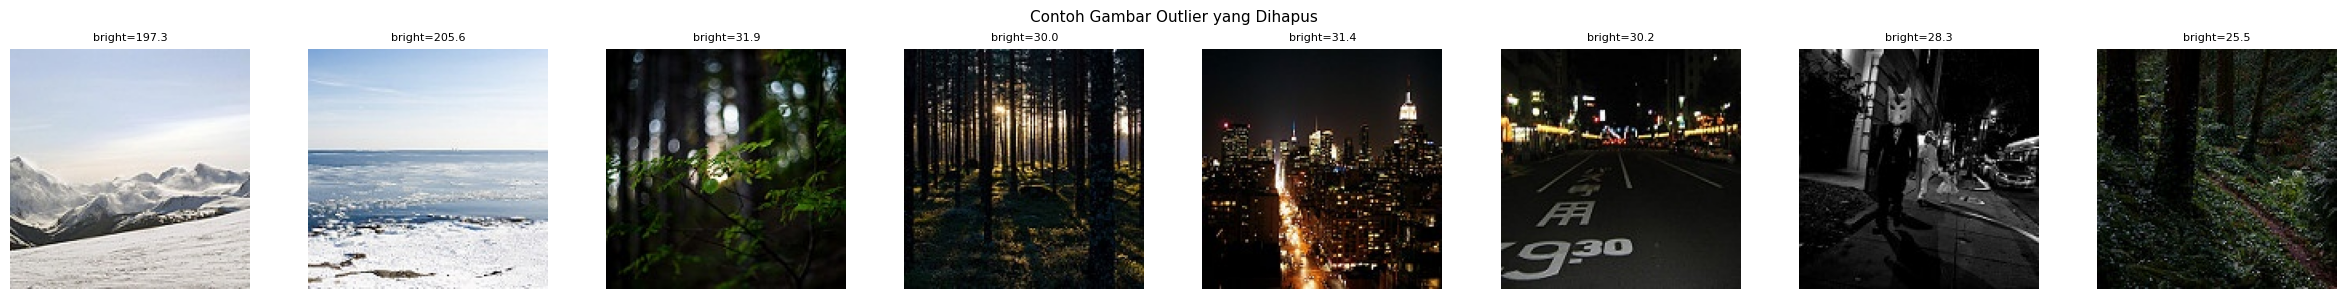

In [42]:
if 'OUTLIER_PATHS_SET' not in globals():
    print("[Warning] OUTLIER_PATHS_SET belum ada. Jalankan sel EDA 1.5 terlebih dahulu.")
    OUTLIER_PATHS_SET = set()

train_paths_all = train_split_df['Full_File_Path'].tolist()
n_before = len(train_paths_all)
n_outlier = sum(1 for p in train_paths_all if p in OUTLIER_PATHS_SET)
n_after   = n_before - n_outlier

print(f"Sebelum filter outlier : {n_before} gambar")
print(f"Outlier dihapus        : {n_outlier} gambar")
print(f"Setelah filter outlier : {n_after} gambar")
print(f"Threshold brightness   : [{OUTLIER_BRIGHTNESS_LOW:.1f}, {OUTLIER_BRIGHTNESS_HIGH:.1f}]")

# Tampilkan contoh gambar outlier
outlier_sample = list(OUTLIER_PATHS_SET)[:8]
if outlier_sample:
    n_show = len(outlier_sample)
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
    if n_show == 1:
        axes = [axes]
    for ax, fp in zip(axes, outlier_sample):
        with Image.open(fp) as img:
            arr = np.array(img.convert('RGB'))
            brightness = arr.mean()
        ax.imshow(arr)
        ax.set_title(f'bright={brightness:.1f}', fontsize=8)
        ax.axis('off')
    plt.suptitle('Contoh Gambar Outlier yang Dihapus', fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Tidak ada outlier ditemukan.")

## 2.4 Data Augmentation

Fungsi augmentasi PIL & layer augmentasi Keras berhasil didefinisikan.
Layer augmentasi: ['random_flip_2', 'random_rotation_2', 'random_brightness_2', 'random_contrast_2', 'random_zoom_2', 'random_translation_2']

Gambar sampel: 0.jpg


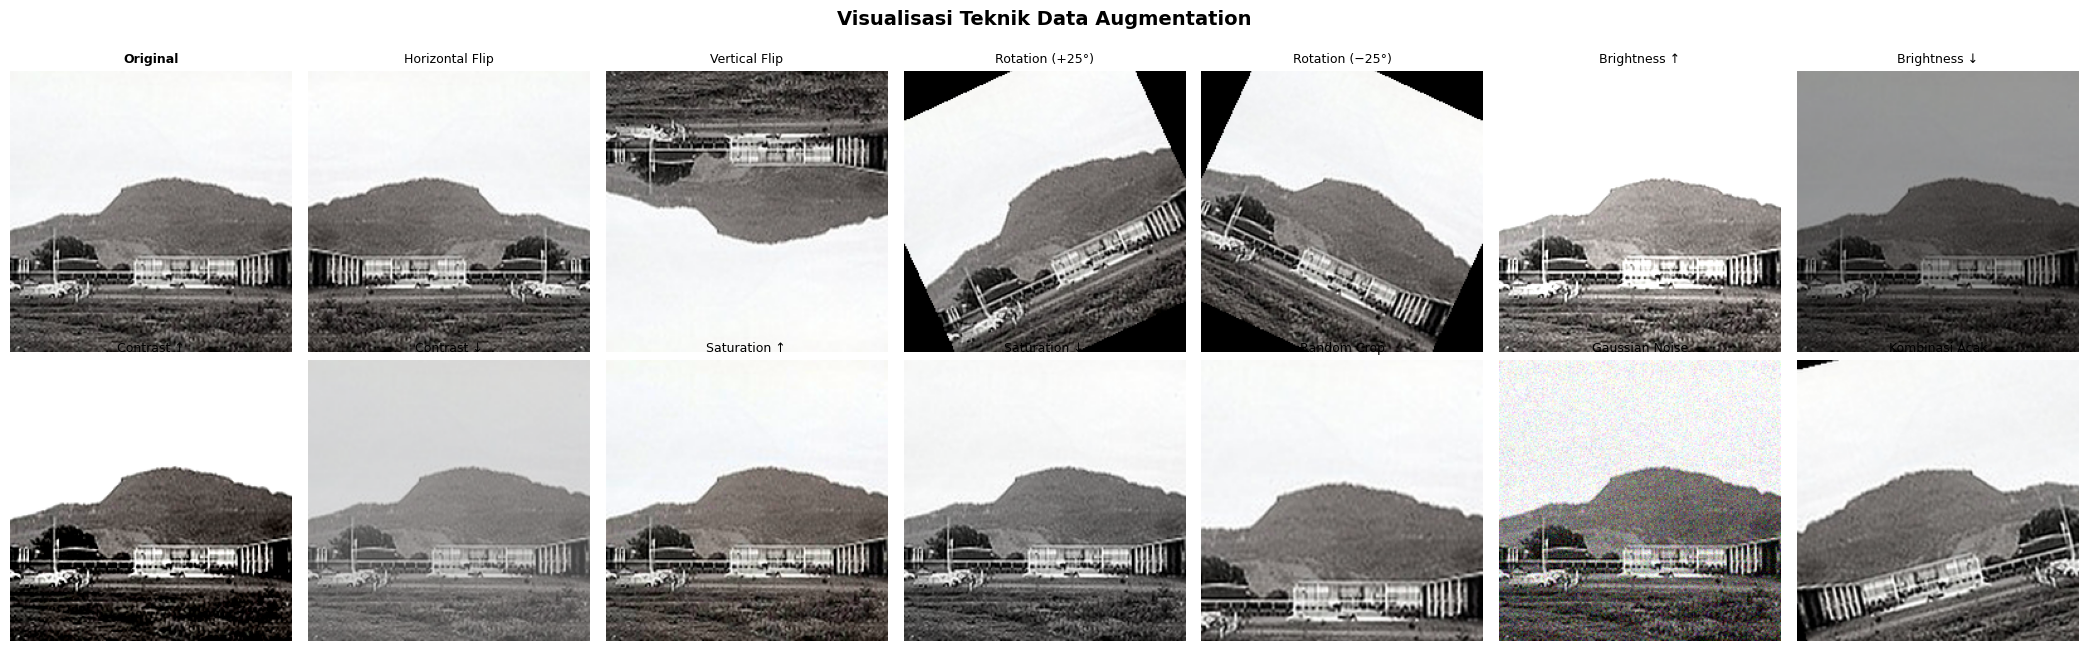


--- Demonstrasi Variasi Augmentasi Acak (1 Gambar → 8 Versi) ---


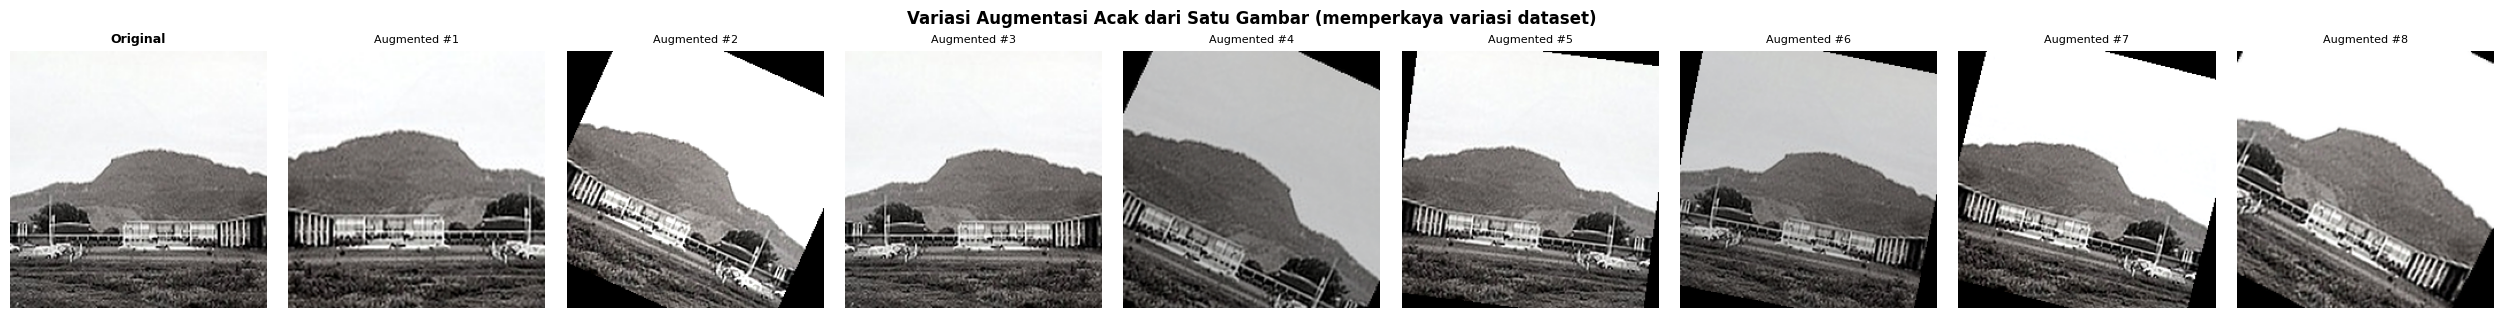


Layer augmentasi Keras siap digunakan dalam model (augmentation_layer).
Gunakan apply_random_augmentation() untuk augmentasi pipeline berbasis PIL.


In [43]:
import tensorflow as tf
from PIL import Image, ImageOps, ImageEnhance
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

# Konfigurasi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. Definisi fungsi augmentasi (PIL-based, untuk eksplorasi visual)

def aug_horizontal_flip(img):
    """Flip horizontal: membalik gambar secara horizontal."""
    return ImageOps.mirror(img)

def aug_vertical_flip(img):
    """Flip vertikal: membalik gambar secara vertikal."""
    return ImageOps.flip(img)

def aug_rotation(img, angle=None):
    """Rotasi acak dalam rentang [-30°, +30°]."""
    if angle is None:
        angle = random.uniform(-30, 30)
    return img.rotate(angle, resample=Image.BICUBIC, expand=False)

def aug_brightness(img, factor=None):
    """Penyesuaian brightness: faktor 0.7–1.3."""
    if factor is None:
        factor = random.uniform(0.7, 1.3)
    return ImageEnhance.Brightness(img).enhance(factor)

def aug_contrast(img, factor=None):
    """Penyesuaian kontras: faktor 0.7–1.3."""
    if factor is None:
        factor = random.uniform(0.7, 1.3)
    return ImageEnhance.Contrast(img).enhance(factor)

def aug_saturation(img, factor=None):
    """Penyesuaian saturasi warna: faktor 0.5–1.5."""
    if factor is None:
        factor = random.uniform(0.5, 1.5)
    return ImageEnhance.Color(img).enhance(factor)

def aug_random_crop(img, crop_ratio=0.85):
    """Random crop: potong sebagian gambar lalu resize ke ukuran semula."""
    w, h = img.size
    cw, ch = int(w * crop_ratio), int(h * crop_ratio)
    left  = random.randint(0, w - cw)
    top   = random.randint(0, h - ch)
    img   = img.crop((left, top, left + cw, top + ch))
    return img.resize((w, h), Image.LANCZOS)

def aug_gaussian_noise(img, std=15):
    """Tambahkan Gaussian noise ke gambar."""
    arr  = np.array(img, dtype=np.float32)
    noise = np.random.normal(0, std, arr.shape)
    arr  = np.clip(arr + noise, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

# 2. Augmentasi kombinasi acak (dipakai saat training)

def apply_random_augmentation(img, p_flip_h=0.5, p_flip_v=0.1,
                               p_rotate=0.5, p_brightness=0.5,
                               p_contrast=0.4, p_saturation=0.4,
                               p_crop=0.3, p_noise=0.2):
    """
    Terapkan augmentasi secara acak berdasarkan probabilitas masing-masing.
    Fungsi ini dapat langsung diintegrasikan ke pipeline preprocessing.
    """
    if random.random() < p_flip_h:
        img = aug_horizontal_flip(img)
    if random.random() < p_flip_v:
        img = aug_vertical_flip(img)
    if random.random() < p_rotate:
        img = aug_rotation(img)
    if random.random() < p_brightness:
        img = aug_brightness(img)
    if random.random() < p_contrast:
        img = aug_contrast(img)
    if random.random() < p_saturation:
        img = aug_saturation(img)
    if random.random() < p_crop:
        img = aug_random_crop(img)
    if random.random() < p_noise:
        img = aug_gaussian_noise(img)
    return img

# 3. Augmentasi TensorFlow-native (dipakai di tf.data pipeline)

def tf_augment(image: tf.Tensor) -> tf.Tensor:
    """
    Augmentasi yang kompatibel dengan tf.data pipeline (graph mode).
    Dipanggil di dalam map() saat membangun dataset training.
    """
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.3)
    image = tf.image.random_saturation(image, lower=0.5, upper=1.5)
    image = tf.image.random_hue(image, max_delta=0.05)

    angle_rad = tf.random.uniform([], -np.pi/6, np.pi/6)
    image = tf.keras.preprocessing.image.apply_affine_transform(
        image.numpy(), theta=float(angle_rad * 180 / np.pi),
        row_axis=0, col_axis=1, channel_axis=2,
        fill_mode='reflect'
    ) if False else image

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(factor=0.083),
    tf.keras.layers.RandomBrightness(factor=0.3),
    tf.keras.layers.RandomContrast(factor=0.3),
    tf.keras.layers.RandomZoom(height_factor=(-0.15, 0.15)),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="data_augmentation")

print("Fungsi augmentasi PIL & layer augmentasi Keras berhasil didefinisikan.")
print(f"Layer augmentasi: {[l.name for l in augmentation_layer.layers]}")


# 4. Visualisasi setiap teknik augmentasi
train_base_path_aug = train_base_path
sample_files = []
for root, _, files in os.walk(train_base_path_aug):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            sample_files.append(os.path.join(root, f))
    if len(sample_files) >= 1:
        break

if not sample_files:
    raise RuntimeError("Tidak ada gambar ditemukan di train_base_path.")

sample_path = sample_files[0]
original_img = Image.open(sample_path).convert("RGB").resize((224, 224), Image.LANCZOS)
print(f"\nGambar sampel: {os.path.basename(sample_path)}")


augmentations = [
    ("Original",          original_img),
    ("Horizontal Flip",   aug_horizontal_flip(original_img)),
    ("Vertical Flip",     aug_vertical_flip(original_img)),
    ("Rotation (+25°)",   aug_rotation(original_img, angle=25)),
    ("Rotation (−25°)",   aug_rotation(original_img, angle=-25)),
    ("Brightness ↑",      aug_brightness(original_img, factor=1.4)),
    ("Brightness ↓",      aug_brightness(original_img, factor=0.6)),
    ("Contrast ↑",        aug_contrast(original_img, factor=1.5)),
    ("Contrast ↓",        aug_contrast(original_img, factor=0.6)),
    ("Saturation ↑",      aug_saturation(original_img, factor=1.8)),
    ("Saturation ↓",      aug_saturation(original_img, factor=0.3)),
    ("Random Crop",       aug_random_crop(original_img, crop_ratio=0.80)),
    ("Gaussian Noise",    aug_gaussian_noise(original_img, std=20)),
    ("Kombinasi Acak",    apply_random_augmentation(original_img.copy())),
]

n_cols = 7
n_rows = (len(augmentations) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3.2))
axes = axes.flatten()

for i, (title, img) in enumerate(augmentations):
    axes[i].imshow(img)
    axes[i].set_title(title, fontsize=9, fontweight='bold' if title == "Original" else 'normal')
    axes[i].axis('off')
    if title == "Original":
        for spine in axes[i].spines.values():
            spine.set_edgecolor('gold')
            spine.set_linewidth(3)
            spine.set_visible(True)

for j in range(len(augmentations), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Visualisasi Teknik Data Augmentation", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# 5. Demonstrasi augmentasi acak berulang pada satu gambar

print("\n--- Demonstrasi Variasi Augmentasi Acak (1 Gambar → 8 Versi) ---")

n_variants = 8
fig2, axes2 = plt.subplots(1, n_variants + 1, figsize=((n_variants + 1) * 2.8, 3.2))

axes2[0].imshow(original_img)
axes2[0].set_title("Original", fontsize=9, fontweight='bold')
axes2[0].axis('off')

for k in range(n_variants):
    aug_img = apply_random_augmentation(original_img.copy())
    axes2[k + 1].imshow(aug_img)
    axes2[k + 1].set_title(f"Augmented #{k+1}", fontsize=8)
    axes2[k + 1].axis('off')

plt.suptitle("Variasi Augmentasi Acak dari Satu Gambar (memperkaya variasi dataset)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nLayer augmentasi Keras siap digunakan dalam model (augmentation_layer).")
print("Gunakan apply_random_augmentation() untuk augmentasi pipeline berbasis PIL.")

# 3. Modelling and Validation

## Setup: Load CNN Dataset

In [44]:
# ── Setup: load CNN dataset ───────────────────────────────────────────────────
import os, sys, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score

sys.path.insert(0, os.path.abspath(".."))

from cnn.utils import build_dataset_from_directory, load_batch
from cnn.train_keras import build_cnn_model, train_one, experiment_name, HYPERPARAMETER_GRID
from cnn.evaluate import (
    evaluate_keras, evaluate_scratch,
    compare_keras_vs_scratch, compare_shared_vs_nonshared,
    plot_history, plot_all_histories, analyze_hyperparameter_effect,
    visualize_predictions, macro_f1
)
from cnn.cnn_scratch import CNNScratch, CNNScratchLC

# ─── Path ke dataset Intel Image Classification ───────────────────────────────
# Sesuaikan dengan path Kaggle / lokal Anda
# (variabel puneet6060_intel_image_classification_path sudah di-set oleh cell setup Kaggle)
INTEL_ROOT = puneet6060_intel_image_classification_path   # dari cell 1

TRAIN_DIR = os.path.join(INTEL_ROOT, "seg_train", "seg_train")
VAL_DIR   = os.path.join(INTEL_ROOT, "seg_test",  "seg_test")   # dipakai juga sbg val
TEST_DIR  = os.path.join(INTEL_ROOT, "seg_test",  "seg_test")

IMG_SIZE = (150, 150)
BATCH_SIZE_CNN = 32

# ─── Load gambar ke numpy ─────────────────────────────────────────────────────
def load_split(split_dir, target_size=IMG_SIZE):
    """Load semua gambar dari split directory ke numpy array."""
    CLASS_NAMES = sorted([
        d for d in os.listdir(split_dir)
        if os.path.isdir(os.path.join(split_dir, d))
    ])
    class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
    paths, labels = [], []
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                paths.append(os.path.join(cls_dir, fname))
                labels.append(class_to_idx[cls])
    print(f"  {split_dir}: {len(paths)} images, {len(CLASS_NAMES)} classes")
    X = load_batch(paths, target_size=target_size)
    y = np.array(labels, dtype=np.int32)
    return X, y, CLASS_NAMES

print("[CNN] Loading train split...")
X_train, y_train, CLASS_NAMES = load_split(TRAIN_DIR)

print("[CNN] Loading val/test split...")
X_test, y_test, _ = load_split(TEST_DIR)

# Gunakan 20% dari train sebagai validation
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Classes: {CLASS_NAMES}")

[CNN] Loading train split...
  C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train: 14034 images, 6 classes
[CNN] Loading val/test split...
  C:\Users\VICTUS 16\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test: 3000 images, 6 classes
Train: (11227, 150, 150, 3), Val: (2807, 150, 150, 3), Test: (3000, 150, 150, 3)
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## 3.1 Perbandingan shared vs non-shared parameter (CNN)

In [ ]:
WEIGHTS_DIR = "weights/cnn"
LOGS_DIR    = "logs/cnn"
PLOTS_DIR   = "plots/cnn"
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(LOGS_DIR,    exist_ok=True)
os.makedirs(PLOTS_DIR,   exist_ok=True)

BEST_NUM_CONV = 4
BEST_FILTERS  = [64, 128]
BEST_KERNEL   = 3
BEST_POOL     = "max"

# Shared (Conv2D)
shared_model = build_cnn_model(
    num_conv_layers=BEST_NUM_CONV,
    filters=BEST_FILTERS,
    kernel_size=BEST_KERNEL,
    pooling_type=BEST_POOL,
    use_locally_connected=False,
)

shared_result = train_one(
    name="shared_best",
    model=shared_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    epochs=20,
    weights_dir=WEIGHTS_DIR,
    logs_dir=LOGS_DIR,
)

# Non-Shared (LocallyConnected2D)
nonshared_model = build_cnn_model(
    num_conv_layers=BEST_NUM_CONV,
    filters=BEST_FILTERS,
    kernel_size=BEST_KERNEL,
    pooling_type=BEST_POOL,
    use_locally_connected=True,
)

nonshared_result = train_one(
    name="nonshared_best",
    model=nonshared_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    epochs=20,
    weights_dir=WEIGHTS_DIR,
    logs_dir=LOGS_DIR,
)

# From-Scratch forward pass
scratch_shared    = CNNScratch.from_keras(shared_model,    non_shared=False)
scratch_nonshared = CNNScratch.from_keras(nonshared_model, non_shared=True)

# Evaluasi & Visualisasi
shared_nonshared_metrics = compare_shared_vs_nonshared(
    keras_shared_model=shared_model,
    keras_nonshared_model=nonshared_model,
    scratch_shared=scratch_shared,
    scratch_nonshared=scratch_nonshared,
    X_test=X_test, y_test=y_test,
    save_dir=PLOTS_DIR,
)

# Training curves
plot_history(shared_result["history"],    "shared_best",    save_dir=PLOTS_DIR)
plot_history(nonshared_result["history"], "nonshared_best", save_dir=PLOTS_DIR)

comparison_df = pd.DataFrame([
    {
        "Model":            "Shared Conv2D",
        "Macro F1 (Keras)": shared_nonshared_metrics["f1_keras_shared"],
        "Macro F1 (Scratch)": shared_nonshared_metrics["f1_scratch_shared"],
        "#Params":          shared_nonshared_metrics["params_shared"],
    },
    {
        "Model":            "Non-Shared LocallyConnected2D",
        "Macro F1 (Keras)": shared_nonshared_metrics["f1_keras_nonshared"],
        "Macro F1 (Scratch)": shared_nonshared_metrics["f1_scratch_nonshared"],
        "#Params":          shared_nonshared_metrics["params_nonshared"],
    },
])
display(comparison_df)



Epoch 1/20


351/351 [==============================] - 826s 2s/step - loss: 1.1325 - accuracy: 0.5631 - val_loss: 0.8105 - val_accuracy: 0.6950
Epoch 2/20
217/351 [=================>............] - ETA: 8:36 - loss: 0.7688 - accuracy: 0.7146

KeyboardInterrupt: 

## 3.2 Pengaruh jumlah layer konvolusi (CNN)

In [ ]:
layer_results = []

for num_layers in HYPERPARAMETER_GRID["num_conv_layers"]:
    model = build_cnn_model(
        num_conv_layers=num_layers,
        filters=[64, 128, 128, 128],
        kernel_size=3,
        pooling_type="max",
    )
    result = train_one(
        name=f"cnn_layers_{num_layers}",
        model=model,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        epochs=20,
        weights_dir=WEIGHTS_DIR,
        logs_dir=LOGS_DIR,
    )
    # evaluasi test F1
    y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=-1)
    test_f1 = macro_f1(y_test, y_pred_test)
    result["test_f1"] = test_f1
    layer_results.append(result)
    plot_history(result["history"], result["name"], save_dir=PLOTS_DIR)

layer_df = pd.DataFrame([
    {"num_layers": int(r["name"].split("_")[-1]),
     "Val F1":  r["best_val_f1"],
     "Test F1": r["test_f1"]}
    for r in layer_results
])
display(layer_df)

## 3.3 Pengaruh banyak filter per layer konvolusi (CNN)

In [ ]:
filter_results = []

for filters in HYPERPARAMETER_GRID["filters"]:
    f_str = "-".join(str(f) for f in filters)
    model = build_cnn_model(
        num_conv_layers=2,
        filters=filters,
        kernel_size=3,
        pooling_type="max",
    )
    result = train_one(
        name=f"cnn_filters_{f_str}",
        model=model,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        epochs=20,
        weights_dir=WEIGHTS_DIR,
        logs_dir=LOGS_DIR,
    )
    y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=-1)
    result["test_f1"] = macro_f1(y_test, y_pred_test)
    result["filters"] = str(filters)
    filter_results.append(result)
    plot_history(result["history"], result["name"], save_dir=PLOTS_DIR)

filter_df = pd.DataFrame([
    {"Filters": r["filters"], "Val F1": r["best_val_f1"], "Test F1": r["test_f1"]}
    for r in filter_results
])
display(filter_df)

## 3.4 Pengaruh ukuran filter per layer konvolusi (CNN)

In [ ]:
kernel_results = []

for ksz in HYPERPARAMETER_GRID["kernel_size"]:   # [3, 5]
    model = build_cnn_model(
        num_conv_layers=2,
        filters=[32, 64],
        kernel_size=ksz,
        pooling_type="max",
    )
    result = train_one(
        name=f"cnn_kernel_{ksz}",
        model=model,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        epochs=20,
        weights_dir=WEIGHTS_DIR,
        logs_dir=LOGS_DIR,
    )
    y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=-1)
    result["test_f1"] = macro_f1(y_test, y_pred_test)
    result["kernel_size"] = ksz
    kernel_results.append(result)
    plot_history(result["history"], result["name"], save_dir=PLOTS_DIR)

kernel_df = pd.DataFrame([
    {"Kernel Size": r["kernel_size"], "Val F1": r["best_val_f1"], "Test F1": r["test_f1"]}
    for r in kernel_results
])
display(kernel_df)


## 3.5 Pengaruh jenis pooling layer (CNN)

In [ ]:
pool_results = []

for pool_type in HYPERPARAMETER_GRID["pooling_type"]:
    model = build_cnn_model(
        num_conv_layers=2,
        filters=[32, 64],
        kernel_size=3,
        pooling_type=pool_type,
    )
    result = train_one(
        name=f"cnn_pool_{pool_type}",
        model=model,
        X_train=X_train, y_train=y_train,
        X_val=X_val,     y_val=y_val,
        epochs=20,
        weights_dir=WEIGHTS_DIR,
        logs_dir=LOGS_DIR,
    )
    y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=-1)
    result["test_f1"] = macro_f1(y_test, y_pred_test)
    result["pooling_type"] = pool_type
    pool_results.append(result)
    plot_history(result["history"], result["name"], save_dir=PLOTS_DIR)

pool_df = pd.DataFrame([
    {"Pooling Type": r["pooling_type"], "Val F1": r["best_val_f1"], "Test F1": r["test_f1"]}
    for r in pool_results
])
display(pool_df)


## 3.6 Semua Kombinasi Hyperparameter

In [ ]:
from cnn.train_keras import train_all_experiments, summarize_results

all_cnn_results = train_all_experiments(
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    epochs=20,
    batch_size=32,
    weights_dir=WEIGHTS_DIR,
    logs_dir=LOGS_DIR,
    skip_existing=True,
)

summary = summarize_results(all_cnn_results)
best_cnn_name = summary["best_name"]

# Plot semua history
plot_all_histories(all_cnn_results, logs_dir=LOGS_DIR, save_dir=PLOTS_DIR)

# Analisis pengaruh hyperparameter
analyze_hyperparameter_effect(all_cnn_results, save_dir=PLOTS_DIR)

print(f"\nModel terbaik: {best_cnn_name}")

## Setup: Flickr8k Feature Extraction & Caption Preprocessing

In [ ]:
import re, os, json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import applications as KA

from cnn.utils import load_batch, extract_and_save_features
from rnn_lstm.train_captioning import (
    build_vocab, make_caption_dataset, build_caption_decoder,
    train_one_decoder, train_all_decoders, generate_caption_greedy,
    evaluate_bleu4, experiment_name as rnn_exp_name,
    EMBED_DIM, VOCAB_SIZE, MAX_LEN, FEATURE_DIM, EPOCHS,
)
from rnn_lstm.captioning_scratch import CaptioningModelScratch, batch_bleu4_scratch
from rnn_lstm.evaluate_captioning import (
    compute_bleu4, compute_meteor,
    keras_generate_batch,
    analyze_hyperparameter_variations,
    plot_training_curves,
    compare_keras_vs_scratch as compare_caption_keras_scratch,
    compare_rnn_vs_lstm,
    analyze_max_len_effect,
)

# Path Flickr8k
FLICKR8K_ROOT    = adityajn105_flickr8k_path
IMAGES_DIR       = os.path.join(FLICKR8K_ROOT, "Images")
CAPTIONS_FILE    = os.path.join(FLICKR8K_ROOT, "captions.txt")
FEATURES_DIR    = "features"
CAPT_WEIGHTS_DIR = "weights/captioning"
CAPT_LOGS_DIR    = "logs/captioning"
CAPT_PLOTS_DIR   = "plots/captioning"

os.makedirs(FEATURES_DIR,    exist_ok=True)
os.makedirs(CAPT_WEIGHTS_DIR, exist_ok=True)
os.makedirs(CAPT_LOGS_DIR,    exist_ok=True)
os.makedirs(CAPT_PLOTS_DIR,   exist_ok=True)

# Baca captions.txt
def load_flickr8k_captions(captions_file):
    captions = {}
    with open(captions_file, "r") as f:
        for i, line in enumerate(f):
            line = line.strip()
            if i == 0 and line.lower().startswith("image"):
                continue   # skip header
            parts = line.split(",", 1)
            if len(parts) != 2:
                continue
            fname, cap = parts[0].strip(), parts[1].strip()
            cap = re.sub(r"[^a-zA-Z0-9 ]", "", cap.lower())
            captions.setdefault(fname, []).append(cap)
    return captions

all_captions = load_flickr8k_captions(CAPTIONS_FILE)
all_fnames   = sorted(all_captions.keys())

# Train / Val / Test split (6000/1000/1000)
np.random.seed(42)
shuffled = np.random.permutation(len(all_fnames))
train_fnames = [all_fnames[i] for i in shuffled[:6000]]
val_fnames   = [all_fnames[i] for i in shuffled[6000:7000]]
test_fnames  = [all_fnames[i] for i in shuffled[7000:8000]]

train_captions = {f: all_captions[f] for f in train_fnames}
val_captions   = {f: all_captions[f] for f in val_fnames}
test_captions  = {f: all_captions[f] for f in test_fnames}

print(f"Train: {len(train_fnames)}, Val: {len(val_fnames)}, Test: {len(test_fnames)}")

# Bangun vocabulary dari training captions
all_train_caps = [cap for caps in train_captions.values() for cap in caps]
word_to_idx, idx_to_word = build_vocab(all_train_caps, vocab_size=VOCAB_SIZE)
print(f"Vocab size: {len(word_to_idx)}")

# Simpan vocab
with open(os.path.join(FEATURES_DIR, "word_to_idx.json"), "w") as f:
    json.dump(word_to_idx, f)
with open(os.path.join(FEATURES_DIR, "idx_to_word.json"), "w") as f:
    json.dump({str(k): v for k, v in idx_to_word.items()}, f)


In [ ]:
INCEPTION_SIZE = (299, 299)

base_cnn = KA.InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(*INCEPTION_SIZE, 3),
)
base_cnn.trainable = False
print("InceptionV3 encoder loaded. Output shape:", base_cnn.output_shape)

def extract_flickr_features(fnames, split_name, images_dir, encoder, img_size=INCEPTION_SIZE):
    """Ekstraksi & cache feature InceptionV3 untuk satu split."""
    out_path = os.path.join(FEATURES_DIR, f"{split_name}_features.npy")
    fname_path = os.path.join(FEATURES_DIR, f"{split_name}_fnames.json")
    
    if os.path.exists(out_path) and os.path.exists(fname_path):
        print(f"[Features] Loading cached {split_name} features from {out_path}")
        feats = np.load(out_path)
        with open(fname_path) as jf:
            cached_fnames = json.load(jf)
        return dict(zip(cached_fnames, feats))
    
    paths = [os.path.join(images_dir, fn) for fn in fnames]
    feats_arr = extract_and_save_features(
        image_paths=paths,
        encoder=encoder,
        output_path=out_path,
        target_size=img_size,
        batch_size=32,
    )
    with open(fname_path, "w") as jf:
        json.dump(fnames, jf)
    return dict(zip(fnames, feats_arr))

train_features = extract_flickr_features(train_fnames, "train", IMAGES_DIR, base_cnn)
val_features   = extract_flickr_features(val_fnames,   "val",   IMAGES_DIR, base_cnn)
test_features  = extract_flickr_features(test_fnames,  "test",  IMAGES_DIR, base_cnn)

print(f"Feature shapes — train: {next(iter(train_features.values())).shape}")


In [ ]:
ACTUAL_FEATURE_DIM = next(iter(train_features.values())).shape[0]

train_ds = make_caption_dataset(
    image_features=train_features,
    image_captions=train_captions,
    word_to_idx=word_to_idx,
    max_len=MAX_LEN,
    batch_size=64,
    shuffle=True,
)
val_ds = make_caption_dataset(
    image_features=val_features,
    image_captions=val_captions,
    word_to_idx=word_to_idx,
    max_len=MAX_LEN,
    batch_size=64,
    shuffle=False,
)
test_ds = make_caption_dataset(
    image_features=test_features,
    image_captions=test_captions,
    word_to_idx=word_to_idx,
    max_len=MAX_LEN,
    batch_size=64,
    shuffle=False,
)

print("Datasets created.")
print(f"  train batches: {len(train_ds)}")
print(f"  val   batches: {len(val_ds)}")


## 3.7 Perbandingan jumlah layer : RNN

In [ ]:
from rnn_lstm.train_captioning import HYPERPARAMETER_GRID as RNN_GRID

rnn_layer_results = []

for num_layers in RNN_GRID["num_rnn_layers"]:   # [1, 2, 3]
    name = rnn_exp_name("rnn", num_layers, 128)
    model = build_caption_decoder(
        rnn_type="rnn",
        num_rnn_layers=num_layers,
        hidden_units=128,
        vocab_size=len(word_to_idx),
        embed_dim=EMBED_DIM,
        feature_dim=ACTUAL_FEATURE_DIM,
        max_len=MAX_LEN,
    )
    result = train_one_decoder(
        name=name,
        model=model,
        train_ds=train_ds,
        val_ds=val_ds,
        epochs=20,
        weights_dir=CAPT_WEIGHTS_DIR,
        logs_dir=CAPT_LOGS_DIR,
    )
    bleu4 = evaluate_bleu4(
        model=model,
        image_features=test_features,
        image_captions=test_captions,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
        n_images=200,
    )
    result.update({"rnn_type": "rnn", "num_layers": num_layers, "hidden_units": 128, "bleu4": bleu4})
    rnn_layer_results.append(result)
    print(f"  [rnn_layers_{num_layers}] BLEU-4: {bleu4:.4f}")

rnn_layer_df = pd.DataFrame([
    {"Num Layers": r["num_layers"], "BLEU-4": r["bleu4"], "Train Time (s)": r["train_time"]}
    for r in rnn_layer_results
])
display(rnn_layer_df)

## 3.8 Perbandingan jumlah layer: LSTM

In [ ]:
lstm_layer_results = []

for num_layers in RNN_GRID["num_rnn_layers"]:   # [1, 2, 3]
    name = rnn_exp_name("lstm", num_layers, 128)
    model = build_caption_decoder(
        rnn_type="lstm",
        num_rnn_layers=num_layers,
        hidden_units=128,
        vocab_size=len(word_to_idx),
        embed_dim=EMBED_DIM,
        feature_dim=ACTUAL_FEATURE_DIM,
        max_len=MAX_LEN,
    )
    result = train_one_decoder(
        name=name,
        model=model,
        train_ds=train_ds,
        val_ds=val_ds,
        epochs=20,
        weights_dir=CAPT_WEIGHTS_DIR,
        logs_dir=CAPT_LOGS_DIR,
    )
    bleu4 = evaluate_bleu4(
        model=model,
        image_features=test_features,
        image_captions=test_captions,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
        n_images=200,
    )
    result.update({"rnn_type": "lstm", "num_layers": num_layers, "hidden_units": 128, "bleu4": bleu4})
    lstm_layer_results.append(result)
    print(f"  [lstm_layers_{num_layers}] BLEU-4: {bleu4:.4f}")

lstm_layer_df = pd.DataFrame([
    {"Num Layers": r["num_layers"], "BLEU-4": r["bleu4"], "Train Time (s)": r["train_time"]}
    for r in lstm_layer_results
])
display(lstm_layer_df)

## 3.9 Perbandingan ukuran hidden state: RNN

In [ ]:
rnn_hidden_results = []

for hidden in RNN_GRID["hidden_units"]:
    name = rnn_exp_name("rnn", 2, hidden)
    model = build_caption_decoder(
        rnn_type="rnn",
        num_rnn_layers=2,
        hidden_units=hidden,
        vocab_size=len(word_to_idx),
        embed_dim=EMBED_DIM,
        feature_dim=ACTUAL_FEATURE_DIM,
        max_len=MAX_LEN,
    )
    result = train_one_decoder(
        name=name,
        model=model,
        train_ds=train_ds,
        val_ds=val_ds,
        epochs=20,
        weights_dir=CAPT_WEIGHTS_DIR,
        logs_dir=CAPT_LOGS_DIR,
    )
    bleu4 = evaluate_bleu4(
        model=model,
        image_features=test_features,
        image_captions=test_captions,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
        n_images=200,
    )
    result.update({"rnn_type": "rnn", "num_layers": 2, "hidden_units": hidden, "bleu4": bleu4})
    rnn_hidden_results.append(result)
    print(f"  [rnn_hidden_{hidden}] BLEU-4: {bleu4:.4f}")

rnn_hidden_df = pd.DataFrame([
    {"Hidden Units": r["hidden_units"], "BLEU-4": r["bleu4"], "Train Time (s)": r["train_time"]}
    for r in rnn_hidden_results
])
display(rnn_hidden_df)

## 3.10 Perbandingan ukuran hidden state: LSTM

In [ ]:
lstm_hidden_results = []

for hidden in RNN_GRID["hidden_units"]:
    name = rnn_exp_name("lstm", 2, hidden)
    model = build_caption_decoder(
        rnn_type="lstm",
        num_rnn_layers=2,
        hidden_units=hidden,
        vocab_size=len(word_to_idx),
        embed_dim=EMBED_DIM,
        feature_dim=ACTUAL_FEATURE_DIM,
        max_len=MAX_LEN,
    )
    result = train_one_decoder(
        name=name,
        model=model,
        train_ds=train_ds,
        val_ds=val_ds,
        epochs=20,
        weights_dir=CAPT_WEIGHTS_DIR,
        logs_dir=CAPT_LOGS_DIR,
    )
    bleu4 = evaluate_bleu4(
        model=model,
        image_features=test_features,
        image_captions=test_captions,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
        n_images=200,
    )
    result.update({"rnn_type": "lstm", "num_layers": 2, "hidden_units": hidden, "bleu4": bleu4})
    lstm_hidden_results.append(result)
    print(f"  [lstm_hidden_{hidden}] BLEU-4: {bleu4:.4f}")

lstm_hidden_df = pd.DataFrame([
    {"Hidden Units": r["hidden_units"], "BLEU-4": r["bleu4"], "Train Time (s)": r["train_time"]}
    for r in lstm_hidden_results
])
display(lstm_hidden_df)

## 3.11 Analisis dan Visualisasi Variasi Hyperparameter RNN/LSTM

In [ ]:
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("omw-1.4", quiet=True)

all_rnn_lstm_results = rnn_layer_results + lstm_layer_results + rnn_hidden_results + lstm_hidden_results

for r in all_rnn_lstm_results:
    gen_out = keras_generate_batch(
        model=r["model"],
        features=test_features,
        captions=test_captions,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
        n_images=100,
    )
    from rnn_lstm.evaluate_captioning import compute_meteor
    r["meteor"] = compute_meteor(gen_out["hypotheses"], gen_out["references"])

# Plot bar chart BLEU-4 & METEOR, pengaruh layer & hidden
analyze_hyperparameter_variations(all_rnn_lstm_results, save_dir=CAPT_PLOTS_DIR)

# Plot training curves
plot_training_curves(all_rnn_lstm_results, save_dir=CAPT_PLOTS_DIR)

summary_df = pd.DataFrame([
    {
        "Name": r["name"],
        "RNN Type": r["rnn_type"].upper(),
        "Layers": r["num_layers"],
        "Hidden": r["hidden_units"],
        "BLEU-4": r.get("bleu4", 0),
        "METEOR": r.get("meteor", 0),
        "Train Time (s)": r["train_time"],
    }
    for r in all_rnn_lstm_results
])
display(summary_df.sort_values("BLEU-4", ascending=False))


## 3.12 Perbandingan RNN vs LSTM

In [ ]:
best_rnn_result  = max([r for r in all_rnn_lstm_results if r["rnn_type"] == "rnn"],
                        key=lambda r: r.get("bleu4", 0))
best_lstm_result = max([r for r in all_rnn_lstm_results if r["rnn_type"] == "lstm"],
                        key=lambda r: r.get("bleu4", 0))

print(f"Best RNN  model : {best_rnn_result['name']}  (BLEU-4={best_rnn_result.get('bleu4',0):.4f})")
print(f"Best LSTM model : {best_lstm_result['name']}  (BLEU-4={best_lstm_result.get('bleu4',0):.4f})")

best_rnn_model  = best_rnn_result["model"]
best_lstm_model = best_lstm_result["model"]

rnn_gen  = keras_generate_batch(best_rnn_model,  test_features, test_captions,
                                 word_to_idx, idx_to_word, max_len=MAX_LEN)
lstm_gen = keras_generate_batch(best_lstm_model, test_features, test_captions,
                                 word_to_idx, idx_to_word, max_len=MAX_LEN)

rnn_vs_lstm_metrics = compare_rnn_vs_lstm(
    rnn_hyps=rnn_gen["hypotheses"],   rnn_refs=rnn_gen["references"],   rnn_time=rnn_gen["time_s"],
    lstm_hyps=lstm_gen["hypotheses"], lstm_refs=lstm_gen["references"], lstm_time=lstm_gen["time_s"],
    image_features=test_features,
    image_captions=test_captions,
    fnames_test=rnn_gen["fnames"],
    n_qualitative=10,
    save_dir=CAPT_PLOTS_DIR,
)
print("RNN vs LSTM metrics:", rnn_vs_lstm_metrics)

## 3.13 Pengaruh panjang maksimum caption terhadap BLEU-4

In [ ]:
overall_best = max(all_rnn_lstm_results,
                   key=lambda r: r.get("bleu4", 0))
print(f"Model terbaik keseluruhan: {overall_best['name']}")

max_len_metrics = analyze_max_len_effect(
    model=overall_best["model"],
    image_features=test_features,
    image_captions=test_captions,
    word_to_idx=word_to_idx,
    idx_to_word=idx_to_word,
    max_len_values=[10, 20, 34, 45],   # ≥ 3 variasi
    is_scratch=False,
    model_name=overall_best["name"],
    save_dir=CAPT_PLOTS_DIR,
    n_images=300,
)

max_len_df = pd.DataFrame([
    {"Max Len": k, "BLEU-4": v} for k, v in sorted(max_len_metrics.items())
])
display(max_len_df)

# 4. Perbandingan Keras vs from scratch

## 4.1 CNN - Forward Propagation From Scratch vs Keras

In [ ]:
best_cnn_weight = os.path.join(WEIGHTS_DIR, f"{best_cnn_name}.keras")
best_keras_model = keras.models.load_model(best_cnn_weight)

print(f"Loaded best CNN model: {best_cnn_name}")
print(f"  Params: {best_keras_model.count_params():,}")

# Build from-scratch models (shared & non-shared)
scratch_cnn_shared    = CNNScratch.from_keras(best_keras_model, non_shared=False)
scratch_cnn_nonshared = CNNScratchLC.from_keras(best_keras_model)   # ganti Conv2D → LocallyConnected2D

# Evaluasi Keras
t0 = time.time()
keras_result_cnn = evaluate_keras(best_keras_model, X_test, y_test)
keras_cnn_time   = time.time() - t0

# Evaluasi Scratch shared
t0 = time.time()
scratch_result_cnn = evaluate_scratch(scratch_cnn_shared, X_test, y_test)
scratch_cnn_time   = time.time() - t0

# Tampilkan perbandingan
compare_keras_vs_scratch(
    keras_result=keras_result_cnn,
    scratch_result=scratch_result_cnn,
    class_names=CLASS_NAMES,
    save_dir=PLOTS_DIR,
)

# Visualisasi prediksi
visualize_predictions(
    X_test=X_test, y_true=y_test,
    y_pred=keras_result_cnn["y_pred"],
    class_names=CLASS_NAMES,
    n_samples=10,
    save_dir=PLOTS_DIR,
    title="cnn_keras_predictions",
)
visualize_predictions(
    X_test=X_test, y_true=y_test,
    y_pred=scratch_result_cnn["y_pred"],
    class_names=CLASS_NAMES,
    n_samples=10,
    save_dir=PLOTS_DIR,
    title="cnn_scratch_predictions",
)

cnn_comparison_df = pd.DataFrame([
    {"Implementation": "Keras (Shared)",    "Macro F1": keras_result_cnn["f1"],   "Time (s)": round(keras_cnn_time, 3)},
    {"Implementation": "Scratch (Shared)",  "Macro F1": scratch_result_cnn["f1"], "Time (s)": round(scratch_cnn_time, 3)},
])
display(cnn_comparison_df)

## 4.2 CNN - Shared vs Non-Shared (From Scratch)

In [ ]:
_parts = best_cnn_name.split("_")
_nc    = int(_parts[0].replace("conv",""))
_filt  = [int(x) for x in _parts[1].replace("f","").split("-")]
_ksz   = int(_parts[2].replace("k",""))
_pool  = _parts[3]

nonshared_best_model = build_cnn_model(
    num_conv_layers=_nc,
    filters=_filt,
    kernel_size=_ksz,
    pooling_type=_pool,
    use_locally_connected=True,
)
nonshared_best_result = train_one(
    name=f"nonshared_{best_cnn_name}",
    model=nonshared_best_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    epochs=20,
    weights_dir=WEIGHTS_DIR,
    logs_dir=LOGS_DIR,
)

scratch_ns = CNNScratch.from_keras(nonshared_best_model, non_shared=True)

compare_shared_vs_nonshared(
    keras_shared_model=best_keras_model,
    keras_nonshared_model=nonshared_best_model,
    scratch_shared=scratch_cnn_shared,
    scratch_nonshared=scratch_ns,
    X_test=X_test, y_test=y_test,
    save_dir=PLOTS_DIR,
)

## 4.3 RNN/LSTM - Forward Propagation From Scratch vs Keras

In [ ]:
for rnn_type, best_result in [("rnn", best_rnn_result), ("lstm", best_lstm_result)]:
    print(f"\n{'='*55}")
    print(f"[{rnn_type.upper()}] Loading best model: {best_result['name']}")
    
    keras_model_cap = keras.models.load_model(best_result["weight_path"])
    
    # Build from-scratch captioning model
    scratch_cap = CaptioningModelScratch(rnn_type=rnn_type)
    scratch_cap.load_weights_from_keras(keras_model_cap)
    
    # Keras generation on test set (subset 200)
    keras_gen = keras_generate_batch(
        model=keras_model_cap,
        features=test_features,
        captions=test_captions,
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
        n_images=200,
    )
    
    # Scratch generation on same images
    scratch_gen = batch_bleu4_scratch(
        scratch_model=scratch_cap,
        image_features={f: test_features[f] for f in keras_gen["fnames"]},
        image_captions={f: test_captions[f] for f in keras_gen["fnames"]},
        word_to_idx=word_to_idx,
        idx_to_word=idx_to_word,
        max_len=MAX_LEN,
    )
    
    # Compare
    compare_caption_keras_scratch(
        keras_hyps=keras_gen["hypotheses"],   keras_refs=keras_gen["references"],   keras_time=keras_gen["time_s"],
        scratch_hyps=scratch_gen["hypotheses"], scratch_refs=scratch_gen["references"], scratch_time=scratch_gen["time_s"],
        rnn_type=rnn_type,
        save_dir=CAPT_PLOTS_DIR,
    )


# 5. Model Persistence

In [ ]:
print("=== Saved CNN Weights ===")
for f in sorted(os.listdir(WEIGHTS_DIR)):
    size = os.path.getsize(os.path.join(WEIGHTS_DIR, f)) / 1024
    print(f"  {f:60s}  {size:8.1f} KB")

print("\n=== Saved Captioning Weights ===")
for f in sorted(os.listdir(CAPT_WEIGHTS_DIR)):
    size = os.path.getsize(os.path.join(CAPT_WEIGHTS_DIR, f)) / 1024
    print(f"  {f:60s}  {size:8.1f} KB")

print("\n[Verify] Re-loading best CNN model and checking F1...")
_reload = keras.models.load_model(os.path.join(WEIGHTS_DIR, f"{best_cnn_name}.keras"))
_pred   = np.argmax(_reload.predict(X_test[:100], verbose=0), axis=-1)
_f1     = macro_f1(y_test[:100], _pred)
print(f"  Best CNN model reloaded — F1 on 100 test samples: {_f1:.4f}")

print("\n[Verify] Re-loading best LSTM captioning model and generating a caption...")
_cap_model = keras.models.load_model(best_lstm_result["weight_path"])
_sample_fname = test_fnames[0]
_sample_feat  = test_features[_sample_fname]
_cap = generate_caption_greedy(_cap_model, _sample_feat, word_to_idx, idx_to_word, max_len=MAX_LEN)
print(f"  Sample caption for '{_sample_fname}': {_cap}")
print(f"  Ground truth: {test_captions[_sample_fname][:2]}")